    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    – Task 2a: Implement a program which, given (a) a query imageID or image file, (b) a user 
    selected feature space, and (c) positive integer k, identifies and lists k most likely 
    matching labels, along with their scores, under the selected feature space.

In [21]:
IMAGE_INPUT = input(
"""
Provide one of the following:
1. An Image ID in the Caltech101 dataset in range [0, 8676].
2. The name of an image file in /Code/input/ directory (eg: image.jpg).
"""
)

FEATURE_SPACE = input("Provide a feature space [color, hog, avgpool, layer3, fc].")

K = int(input("Enter K, the number of similar labels to find for the selected feature space."))

Files already downloaded and verified
Input image:  2500


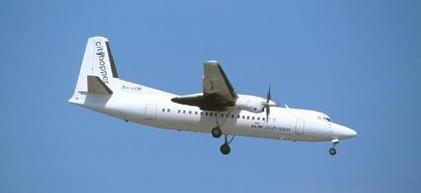

In [22]:
# Find the k most likely matching labels for a given query image for the given feature space.

from utils.query_input_processor import get_query_image

image = get_query_image(IMAGE_INPUT)

print("Input image: ", IMAGE_INPUT)
display(image)

In [23]:
if FEATURE_SPACE == 'color':
    from feature_models.color_moments import ColorMomentsExtractor

    vector = ColorMomentsExtractor(image).get_color_vector()

elif FEATURE_SPACE == 'hog':
    from feature_models.hog import HOGExtractor

    vector = HOGExtractor(image).get_hog_vector()

else:
    # ResNet feature model.
    from feature_models.resnet import ResNetExtractor
    resnet = ResNetExtractor(image)

    if FEATURE_SPACE == 'avgpool':
        vector = resnet.get_avgpool_vector()

    elif FEATURE_SPACE == 'layer3':
        vector = resnet.get_layer3_vector()

    else:
        # fc feature space.
        vector = resnet.get_fc_vector()

In [24]:
# Load representative label vectors in the feature space.

from utils.database_utils import retrieve

rep_label_vectors = retrieve(f'rep_label_{FEATURE_SPACE}.pt')

In [25]:
# Convert representative label vectors to feature vectors for usage with distance utils.
# We take care not to use the key of this dictionary as IMG_ID.

from utils.vector_utils import rep_label_vectors_to_feature_vectors
rep_feature_vectors = rep_label_vectors_to_feature_vectors(rep_label_vectors)

from utils.distance_utils import get_distance_fn, top_k_unique_label_distance_ranker
distances = top_k_unique_label_distance_ranker(K, vector, rep_feature_vectors, get_distance_fn(FEATURE_SPACE))

print("\nK =", K, " most similar labels by ", FEATURE_SPACE, " feature space using distance: ", get_distance_fn(FEATURE_SPACE).__name__)

for i in range(len(distances)):
    distance, dummy_img_id, label = distances[i]

    print(str(i + 1) + ".", "\tLabel: \t", label, "\t\tDistance: ", distance)




K = 5  most similar labels by  fc  feature space using distance:  cosine
1. 	Label: 	 airplanes 		Distance:  0.050704240798950195
2. 	Label: 	 helicopter 		Distance:  0.34586822986602783
3. 	Label: 	 ferry 		Distance:  0.7044166922569275
4. 	Label: 	 brontosaurus 		Distance:  0.7460162043571472
5. 	Label: 	 metronome 		Distance:  0.7677018642425537
